# Fetch Pull Combined loss

In [1]:
from pathlib import Path
import sys
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
import time
import copy


# Resolve repository src path robustly when running notebook in-place.
repo_root = Path.cwd()
while repo_root != repo_root.parent and not (repo_root / 'src').exists():
    repo_root = repo_root.parent
sys.path.insert(0, str(repo_root / 'src'))

from environments.fetch_push_env import make_env
from utils import set_seed, estimate_fisher_diag, compute_embedding_drift, collect_weight_snapshot, TrajectoryReplayBuffer
from visualisations import visualise_embeddings, visualise_q_table, print_goal_embedding_similarity, plot_full_embedding_dashboard_2d_html, plot_min_steps_and_min_time
from networks import Factorised_TD3_Critic
from agents import Factorised_TD3_Actor
from trainer import td3_train, sac_train


DEVICE = 'cuda' if torch.cuda.is_available() else ('mps' if torch.backends.mps.is_available() else 'cpu')
print('Using device:', DEVICE)


AdroitHandRelocateDense-v1, AdroitHandHammerDense-v1, AdroitHandDoorDense-v1 environment's reward functions were updated in v1.2.1 without an environment version update. Therefore, use gymnasium-robotics==1.2.0 for v1 reproducibility or use v2 in gymnasium-robotics>=1.4.3. See https://github.com/Farama-Foundation/Gymnasium-Robotics/pull/220 for more details


Using device: mps


In [2]:
FETCH_REACH_LABELS = [
    "ee_x",
    "ee_y",
    "ee_z",
    "right_gripper_finger_joint_pos",
    "left_gripper_finger_joint_pos",
    "ee_vx",
    "ee_vy",
    "ee_vz",
    "right_gripper_finger_vel",
    "left_gripper_finger_vel",
]

def print_fetch_obs(obs):
    if isinstance(obs, dict):
        vec = obs["observation"]
        achieved = obs.get("achieved_goal", None)
        desired = obs.get("desired_goal", None)
    else:
        vec = obs
        achieved = None
        desired = None

    vec = np.asarray(vec).reshape(-1)

    print("Observation length:", len(vec))
    for i, (label, value) in enumerate(zip(FETCH_REACH_LABELS, vec)):
        print(f"{i:02d} {label:25s} {value: .6f}")

    if achieved is not None:
        print("\nachieved_goal:", np.asarray(achieved))
    if desired is not None:
        print("desired_goal  :", np.asarray(desired))

Observation length: 16
00 ee_x                       1.341833
01 ee_y                       0.749101
02 ee_z                       0.534733
03 right_gripper_finger_joint_pos  0.000385
04 left_gripper_finger_joint_pos  0.000010
05 ee_vx                     -0.000006
06 ee_vy                     -0.000000
07 ee_vz                      0.000021
08 right_gripper_finger_vel   0.000006
09 left_gripper_finger_vel   -0.000003


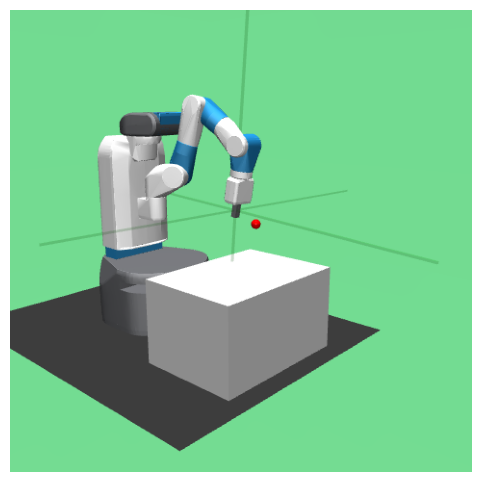

Observation space: Box(-inf, inf, (16,), float32)
Action space: Box(-1.0, 1.0, (4,), float32)
Obs dim: (16,)
Action dim: (4,)


In [3]:
goal = np.array([1.20, 0.75, 0.42], dtype=np.float32)

env_fn = make_env(
    goal=goal,
    reward_type="dense",
    max_episode_steps=100,
    render_mode="rgb_array",
    flatten_obs=True,
    goal_radius=0.05,
    use_native_reward=True,
)

env = env_fn()
obs, info = env.reset()
print_fetch_obs(obs)

frames = []

obs, info = env.reset()
done = False
while not done:
    frame = env.render()
    if frame is not None:
        frames.append(frame)

    action = env.action_space.sample()
    obs, reward, terminated, truncated, info = env.step(action)
    done = terminated or truncated

plt.figure(figsize=(6, 6))
plt.imshow(frames[-1])
plt.axis("off")
plt.show()

env = env_fn()

print("Observation space:", env.observation_space)
print("Action space:", env.action_space)

print("Obs dim:", env.observation_space.shape)
print("Action dim:", env.action_space.shape)



In [4]:
goal = np.array([1.20, 0.75, 0.42], dtype=np.float32)

BUFFER_CAPACITY = 200_000
env_fn = make_env(
    goal=goal,
    reward_type="dense",
    max_episode_steps=50,
    render_mode=None,
    flatten_obs=True,
    goal_radius=0.05,
    use_native_reward=True,
)

env = env_fn()
obs, info = env.reset()

obs_dim = 10
act_dim = env.action_space.shape[0]
goal_dim = 3


# Instantiate the networks expected by your trainer
actor_curr = Factorised_TD3_Actor(obs_dim, act_dim, goal_dim).to(DEVICE)
actor_tgt_curr = Factorised_TD3_Actor(obs_dim, act_dim, goal_dim).to(DEVICE)
q1_curr = Factorised_TD3_Critic(obs_dim, act_dim, goal_dim).to(DEVICE)
q2_curr = Factorised_TD3_Critic(obs_dim, act_dim, goal_dim).to(DEVICE)
q1_tgt_curr = Factorised_TD3_Critic(obs_dim, act_dim, goal_dim).to(DEVICE)
q2_tgt_curr = Factorised_TD3_Critic(obs_dim, act_dim, goal_dim).to(DEVICE)

(
    actor_trained,
    actor_tgt_trained,
    q1_main,
    q1_tgt_main,
    q2_trained,
    q2_tgt_trained,
    eval_returns,
    min_steps,
    min_time,
    task_embedding,
    sa_embedding_mean,
    sa_embedding_fixed,
    sa_batch_final,
    replay,
) = td3_train(
    seed=42,
    actor=actor_curr,
    actor_tgt=actor_tgt_curr,
    q1=q1_curr,
    q2=q2_curr,
    q1_tgt=q1_tgt_curr,
    q2_tgt=q2_tgt_curr,
    env=env,
    make_env=make_env(goal=goal),
    goal=goal,
    buffer_capacity=BUFFER_CAPACITY,
    total_steps=500_000,
    warmup_steps=10_000,
    batch_size=256,
    gamma=0.99,
    tau=0.005,
    policy_noise=0.2,
    noise_clip=0.5,
    policy_delay=2,
    expl_noise=0.3,
    lr=3e-4,
    train_freq=2,
    gradient_steps=1,
    eval_every=5_000,
    device=DEVICE,
    obs_dim=obs_dim,
    act_dim=act_dim,
    early_stop_reward=-2.0,
    enable_early_stop=True,
)
if eval_returns:
    xs, ys = zip(*eval_returns)
    plt.figure(figsize=(7, 4))
    plt.plot(xs, ys)
    plt.xlabel("Environment steps")
    plt.ylabel("Mean episodic return")
    plt.title("TD3 baseline on Walker Walk")
    plt.grid(alpha=0.25)
    plt.show()

KeyboardInterrupt: 

In [5]:
class Factorised_SAC_Actor(nn.Module):
    def __init__(
        self,
        obs_dim: int,
        act_dim: int,
        goal_dim: int = 3,
        hidden_dim: int = 256,
        logstd_init: float = 0.0,
    ):
        super().__init__()
        self.obs_dim = obs_dim
        self.act_dim = act_dim
        self.goal_dim = goal_dim

        self.net = nn.Sequential(
            nn.Linear(obs_dim + goal_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
        )

        self.mean_head = nn.Linear(hidden_dim, act_dim)
        self.logstd_head = nn.Linear(hidden_dim, act_dim)

        # Initialize log-std to a reasonable value
        nn.init.constant_(self.logstd_head.weight, 0.0)
        nn.init.constant_(self.logstd_head.bias, logstd_init)

    def forward(self, obs: torch.Tensor, goal: torch.Tensor):
        """
        obs:  [B, obs_dim]
        goal: [B, goal_dim]
        returns: mean [B, act_dim], logstd [B, act_dim]
        """
        x = torch.cat([obs, goal], dim=-1)
        h = self.net(x)
        mean = self.mean_head(h)
        logstd = self.logstd_head(h)
        # Optional: clamp logstd for numerical stability
        logstd = torch.clamp(logstd, -20.0, 2.0)
        return mean, logstd

    def sample(self, obs: torch.Tensor, goal: torch.Tensor):
        """
        Sample actions from the policy.
        Returns: action [B, act_dim], log_prob [B, 1]
        """
        mean, logstd = self.forward(obs, goal)
        std = logstd.exp()
        dist = torch.distributions.Normal(mean, std)
        action = dist.rsample()
        log_prob = dist.log_prob(action).sum(dim=-1, keepdim=True)
        return action, log_prob

    def evaluate(self, obs: torch.Tensor, goal: torch.Tensor, actions: torch.Tensor):
        """
        Compute log-prob of given actions under the current policy.
        actions: [B, act_dim]
        Returns: log_prob [B, 1]
        """
        mean, logstd = self.forward(obs, goal)
        std = logstd.exp()
        dist = torch.distributions.Normal(mean, std)
        log_prob = dist.log_prob(actions).sum(dim=-1, keepdim=True)
        return log_prob

class Factorised_SAC_Critic(nn.Module):
    def __init__(
        self,
        obs_dim: int,
        act_dim: int,
        goal_dim: int = 3,
        hidden_dim: int = 256,
        emb_dim: int = 256,
    ):
        super().__init__()
        self.obs_dim = obs_dim
        self.act_dim = act_dim
        self.goal_dim = goal_dim
        self.emb_dim = emb_dim

        # SA encoder: phi(s, a)
        self.sa_net = nn.Sequential(
            nn.Linear(obs_dim + act_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, emb_dim),
        )

        # Goal encoder: psi(g)
        self.goal_net = nn.Sequential(
            nn.Linear(goal_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, emb_dim),
        )

        # Final Q-head: dot product or small network.
        # Here we use a small network on top of the elementwise product.
        self.q_head = nn.Sequential(
            nn.Linear(emb_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, obs: torch.Tensor, action: torch.Tensor, goal: torch.Tensor):
        """
        obs:    [B, obs_dim]
        action: [B, act_dim]
        goal:   [B, goal_dim]
        returns: Q-value [B, 1]
        """
        # SA embedding
        sa = torch.cat([obs, action], dim=-1)
        phi = self.sa_net(sa)           # [B, emb_dim]

        # Goal embedding
        psi = self.goal_net(goal)       # [B, emb_dim]

        # Combine: elementwise product (could also use concat or dot)
        x = phi * psi                   # [B, emb_dim]

        # Q-value
        q = self.q_head(x)              # [B, 1]
        return torch.clamp(q, -100.0, 100.0)  # or some reasonable range

    def encode_sa(self, obs: torch.Tensor, action: torch.Tensor):
        """Return phi(s,a) embedding."""
        sa = torch.cat([obs, action], dim=-1)
        return self.sa_net(sa)

    def encode_goal(self, goal: torch.Tensor):
        """Return psi(g) embedding."""
        return self.goal_net(goal)

In [ ]:

goal = np.array([0.0, 0.6, 0.42], dtype=np.float32)  # example; adjust to your setup

env_fn = make_env(
    goal=goal,
    reward_type="dense",
    max_episode_steps=50,
    render_mode="rgb_array",
    flatten_obs=True,
    goal_radius=0.05,
    use_native_reward=True,
)

env = env_fn()

# -------------------------
# Dimensions
# -------------------------
# With your wrapper: flat obs = [obs(10), achieved_goal(3), desired_goal(3)]
full_obs_dim = env.observation_space.shape[0]  # should be 16
obs_dim = full_obs_dim - 6                     # 10
act_dim = env.action_space.shape[0]            # 4
goal_dim = 3

# -------------------------
# Models
# -------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

actor_curr = Factorised_SAC_Actor(
    obs_dim=obs_dim,
    act_dim=act_dim,
    goal_dim=goal_dim,
    hidden_dim=256,
    logstd_init=0.0,
).to(device)

actor_tgt = Factorised_SAC_Actor(
    obs_dim=obs_dim,
    act_dim=act_dim,
    goal_dim=goal_dim,
    hidden_dim=256,
    logstd_init=0.0,
).to(device)
actor_tgt.load_state_dict(actor_curr.state_dict())

q1_curr = Factorised_SAC_Critic(
    obs_dim=obs_dim,
    act_dim=act_dim,
    goal_dim=goal_dim,
    hidden_dim=256,
    emb_dim=256,
).to(device)

q2_curr = Factorised_SAC_Critic(
    obs_dim=obs_dim,
    act_dim=act_dim,
    goal_dim=goal_dim,
    hidden_dim=256,
    emb_dim=256,
).to(device)

q1_tgt = Factorised_SAC_Critic(
    obs_dim=obs_dim,
    act_dim=act_dim,
    goal_dim=goal_dim,
    hidden_dim=256,
    emb_dim=256,
).to(device)

q2_tgt = Factorised_SAC_Critic(
    obs_dim=obs_dim,
    act_dim=act_dim,
    goal_dim=goal_dim,
    hidden_dim=256,
    emb_dim=256,
).to(device)

q1_tgt.load_state_dict(q1_curr.state_dict())
q2_tgt.load_state_dict(q2_curr.state_dict())

# -------------------------
# Train
# -------------------------
(
    actor_trained,
    actor_tgt_trained,
    q1_trained,
    q1_tgt_trained,
    q2_trained,
    q2_tgt_trained,
    eval_returns,
    min_steps,
    min_time,
    task_embedding,
    sa_embedding_mean,
    sa_embedding_fixed,
    sa_batch_final,
    replay,
) = sac_train(
    seed=42,
    actor=actor_curr,
    actor_tgt=actor_tgt,
    q1=q1_curr,
    q2=q2_curr,
    q1_tgt=q1_tgt,
    q2_tgt=q2_tgt,
    env=env,
    make_env=make_env,
    goal=goal,
    buffer_capacity=100000,
    total_steps=500000,
    warmup_steps=10000,
    batch_size=256,
    gamma=0.99,
    tau=0.005,
    lr=1e-4,
    train_freq=1,
    gradient_steps=1,
    eval_every=1000,
    device=device,
    obs_dim=obs_dim,
    act_dim=act_dim,
    alpha=0.2,
    fixed_alpha=True,
    target_entropy=-act_dim,
    early_stop_reward=-0.5,
    early_stop_patience=5,
    enable_early_stop=True,
)

[SAC-factorised] step=  11000 | train_it=   1000 | eval_return=-43.750 | eval_len=43.9 | critic_loss=16.223 | actor_loss=-115.154 | alpha=1.120
[SAC-factorised] step=  12000 | train_it=   2000 | eval_return=-50.000 | eval_len=50.0 | critic_loss=14.663 | actor_loss=-117.138 | alpha=1.240
[SAC-factorised] step=  13000 | train_it=   3000 | eval_return=-43.875 | eval_len=44.0 | critic_loss=31.100 | actor_loss=-118.668 | alpha=1.371
[SAC-factorised] step=  14000 | train_it=   4000 | eval_return=-50.000 | eval_len=50.0 | critic_loss=97.154 | actor_loss=-120.590 | alpha=1.515
[SAC-factorised] step=  15000 | train_it=   5000 | eval_return=-50.000 | eval_len=50.0 | critic_loss=121.598 | actor_loss=-123.213 | alpha=1.675


KeyboardInterrupt: 